In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_pickle("../../data/processed/18_cleaned_master_data.pkl")

# Feature Engineering: Alter beim Rennen

age_at_race = year - birth_year

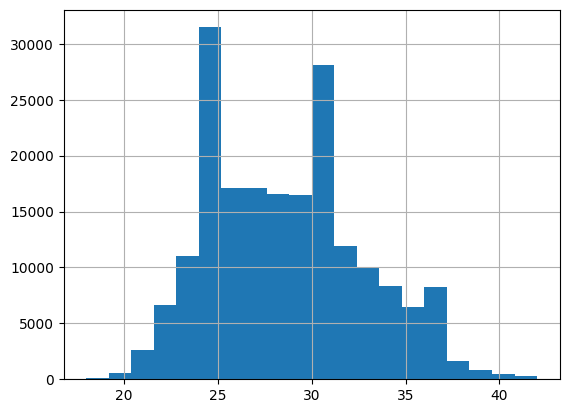

Fehlende birthdate: 0
Fehlende age_at_race: 0


In [ ]:
df["birth_year"] = pd.to_datetime(df["birthdate"]).dt.year
df["age_at_race"] = (
    (pd.to_datetime(df["date"]) - pd.to_datetime(df["birthdate"], errors="coerce"))
    .dt.days // 365
)
df = df.drop(columns=["birth_year"])

df["age_at_race"].hist(bins=20)
plt.show()

# Fehlende Geburtsdaten
df["birthdate"] = pd.to_datetime(df["birthdate"], errors="coerce")
missing = df["birthdate"].isna().sum()
print(f"Fehlende birthdate: {missing}")
print(f"Fehlende age_at_race: {df['age_at_race'].isna().sum()}")

In [4]:
# Plausibilitätsprüfung
df["age_at_race"].describe()

count    196048.000000
mean         28.536767
std           4.121818
min          18.000000
25%          25.000000
50%          28.000000
75%          31.000000
max          42.000000
Name: age_at_race, dtype: float64

#### Stichprobe zum Prüfen der Berechnung

In [6]:
cols = ["name", "year", "date", "birthdate", "age_at_race"]
df[cols].drop_duplicates(["name", "year"]).sample(10, random_state=42)

,name,year,date,birthdate,age_at_race
8997,Fabian Cancellara,2008,2008-07-05,1981-03-18,27
51825,Julien Simon,2021,2021-06-26,1985-10-04,35
111278,Nicola Bagioli,2019,2019-05-12,1995-02-19,24
32183,Thomas Voeckler,2015,2015-07-05,1979-06-22,36
123036,Francesco Gavazzi,2023,2023-05-07,1984-08-01,38
82288,Mauricio Alberto Ardila,2010,2010-05-09,1979-05-21,30
15120,Sébastien Minard,2010,2010-07-04,1982-06-12,28
175839,Mark Padun,2019,2019-08-25,1996-07-06,23
108058,Mads Pedersen,2018,2018-05-05,1995-12-18,22
45470,Jasper Philipsen,2019,2019-07-06,1998-03-02,21


## Implementierung & Checkpoint

**Input:**  `18_cleaned_master_data.pkl`  
**Output:** `19_cleaned_master_data.pkl`  

**Änderungen:**
- Neue Spalte `age_at_race` (integer)
- Hilfsspalte `birth_year` wieder entfernt

In [7]:
pfad = "../../data/processed/19_cleaned_master_data.pkl"
df.to_pickle(pfad)
print(f"Gespeichert: {pfad}")

Gespeichert: ../../data/processed/19_cleaned_master_data.pkl
